<a href="https://colab.research.google.com/github/tasneemsk500/Basic_Instagram_Page_Clone/blob/main/Tasneem_Shahnewaz_Khan_A6_cifar10_ann_cnn_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6: Image Classification on CIFAR-10 (ANN vs CNN)

**Objective**
* Practicing Keras and implementing ANN and CNN using Keras
* Build and compare for image classification using :
  - ANN (Artificial Neural Network)
  - CNN (Convolutional Neural Network)
Understand why CNN works better for images.


**This notebook is incomplete. You need to carefully read the codes and instructions. Some places you need to add some code and in some places you need to explain with text and comments. Make sure your submitted notebook has all the output including the full code**
 <br>
<font color="red"> If you see the label <u><b>#TODO </b></u> anywhere in the notebook, it indicates that you need to complete that section by writing code or adding text to answer the question.</font>

In [ ]:
#importing some necessary libraries
from keras.datasets import cifar10
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


###TODO
What do the numbers (50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), and (10000, 1) represent in the output above??
* (50000, 32, 32, 3): There are 50000 images of size 32x32 with 3 colour channels such as red, blue and green
* (10000, 32, 32, 3): There are 10000 images of size 32x32 with 3 colour channels such as red, blue and green
* (50000, 1): For each 50000 images there is a label (Y_train)
* (10000, 1): For each 10000 images there is a label (Y_test)




array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
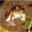

In [ ]:
#checking one image data
x_train[0]

## Visualization (Given)

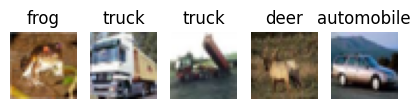

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(5,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

## Task #TODO: Show 10 Random Images

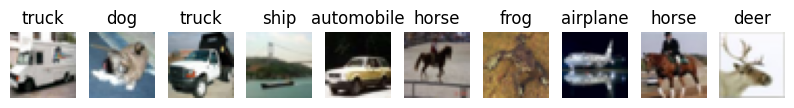

In [ ]:
# TODO
plt.figure(figsize=(10,4))
# your code
for i in range(10):
    #generate the random indices
    rnd_index = np.random.randint(0, x_train.shape[0])
    plt.subplot(1,10,i+1) #change the grid number to 10
    plt.imshow(x_train[rnd_index])
    plt.title(class_names[y_train[rnd_index][0]])
    plt.axis('off')

plt.show()

# Part 1: Developing Artifican Neural Network (Follow the codes from the slide!)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

## Preprocessing

In [ ]:
num_pixels = x_train.shape[1] * x_train.shape[2] * x_train.shape[3]  #calculating total number of features for each image
print(num_pixels)

x_train = x_train.reshape(x_train.shape[0], num_pixels).astype('float32') #TODO: reshape x_train to number of images X number of features calculated above
x_test = x_test.reshape(x_test.shape[0], num_pixels).astype('float32') #TODO: reshape x_test to number of images X number of features calculated above
print(x_train.shape, x_test.shape)  #this should output (50000, 3072) (10000, 3072)

3072
(50000, 3072) (10000, 3072)


In [ ]:
x_train[0] #just printing one image to see if it has been reshaped

array([ 59.,  62.,  63., ..., 123.,  92.,  72.], dtype=float32)

In [ ]:
x_train = x_train / 255 #TODO: Normalize the pixel values of x_train
x_test = x_test / 255 #TODO: Normalize the pixel values of x_test

y_train = to_categorical(y_train)  #TODO:perform one hot encoding for y_train using to_categorial function
y_test = to_categorical(y_test)    #TODO:perform one hot encoding for y_test using to_categorial function

print(x_train.shape, y_train.shape) #should print this (50000, 3072) (50000, 10)

(50000, 3072) (50000, 10)


In [ ]:
#imported this libreary to fix the missing models function later in the def simplen function for code cell 60
from keras import models, Input

In [ ]:
num_classes = 10
# define simple model
def simplenn_model():
  model = models.Sequential()
  #TODO: add input layer (Check the updated keras MNIST pdf on webcourses .)
  model.add(Input(shape=(num_pixels,)))
  #TODO: add 3 Dense layers in three lines (first dense layer should have 1000 nurons, second one 100 and third one 50 neurons). All of htem should use normal kernal_initializer and relu activation
  model.add(Dense(1000, kernel_initializer='normal', activation='relu'))
  model.add(Dense(100, kernel_initializer='normal', activation='relu'))
  model.add(Dense(50, kernel_initializer='normal', activation='relu'))
  #TODO: add output layer with appropriate number of nurons based on the number of classes we are workig on, normal kernal initilaizer and softmax activation
  model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))
  # Compile model
  #TODO: setup compile with categorical cross entropy as the loss, adam optimizer and metrics['accuracy']
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

  return model

In [ ]:
# build the model
model = simplenn_model()
# Fit the model (this is the training)
#TODO train the model and pass the appropriate parameters, use 10 epoch and 200 batch size (it may take time. If you see it is taking more than 30 minutes, then reduce epoch. For me, it took 30 seconds per epcoh in google colab)
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs= 10, batch_size= 200, verbose=2)

Epoch 1/10
250/250 - 15s - 61ms/step - accuracy: 0.2989 - loss: 1.9135 - val_accuracy: 0.3459 - val_loss: 1.7771
Epoch 2/10
250/250 - 20s - 81ms/step - accuracy: 0.3825 - loss: 1.7130 - val_accuracy: 0.4032 - val_loss: 1.6388
Epoch 3/10
250/250 - 20s - 81ms/step - accuracy: 0.4201 - loss: 1.6250 - val_accuracy: 0.4290 - val_loss: 1.5900
Epoch 4/10
250/250 - 14s - 54ms/step - accuracy: 0.4426 - loss: 1.5597 - val_accuracy: 0.4458 - val_loss: 1.5321
Epoch 5/10
250/250 - 14s - 56ms/step - accuracy: 0.4584 - loss: 1.5170 - val_accuracy: 0.4660 - val_loss: 1.4952
Epoch 6/10
250/250 - 14s - 55ms/step - accuracy: 0.4741 - loss: 1.4707 - val_accuracy: 0.4742 - val_loss: 1.4753
Epoch 7/10
250/250 - 14s - 56ms/step - accuracy: 0.4837 - loss: 1.4404 - val_accuracy: 0.4794 - val_loss: 1.4653
Epoch 8/10
250/250 - 14s - 55ms/step - accuracy: 0.4981 - loss: 1.4067 - val_accuracy: 0.4808 - val_loss: 1.4601
Epoch 9/10
250/250 - 20s - 82ms/step - accuracy: 0.5057 - loss: 1.3890 - val_accuracy: 0.4997 - 

##TASK #TODO ***What was the last accuracy from training set: 0.5206 and validation set: 0.4963**

In [ ]:
#TODO: Print the model summary
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1000)           │     3,073,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │       100,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,535,982 (36.38 MB)

 Trainable params: 3,178,660 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,357,322 (24.25 MB)

None


In [ ]:
print(model.evaluate(x_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4963 - loss: 1.4064
[1.4064247608184814, 0.49630001187324524]


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Convert one-hot TRUE labels to integer indices
y_true_indices = np.argmax(y_test, axis=1)

# 2. Get model predictions (probabilities)
y_pred_probs = model.predict(x_test)

# 3. Convert predicted probabilities to integer indices
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# 4. Generate the report
print(classification_report(y_true_indices, y_pred_indices))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

           0       0.52      0.63      0.57      1000
           1       0.63      0.60      0.61      1000
           2       0.38      0.37      0.37      1000
           3       0.35      0.20      0.25      1000
           4       0.44      0.43      0.44      1000
           5       0.35      0.51      0.41      1000
           6       0.47      0.62      0.54      1000
           7       0.66      0.43      0.53      1000
           8       0.68      0.58      0.63      1000
           9       0.56      0.60      0.58      1000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000



Part 2: Developing Convolutional Neural Network (CNN) (Follow the codes from the slide!)

In [ ]:
# To see plots "in-line" in your Notebook, you must use this command
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,7) # Make the figures a bit bigger

import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import layers, models, Input
from keras import backend as K

In [ ]:
#read the data set
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


In [ ]:
#reshape train test based based backend
# input image dimensions
img_rows, img_cols = x_train.shape[1], x_train.shape[2]
channel = 3 #TODO fill out number of channel for our images
#don’t forget. X_train.shape was (60000, 28, 28). In our case it is just one channel

if K.image_data_format() == 'channels_first':
   x_train = x_train.reshape(x_train.shape[0], channel, img_rows, img_cols) #(50000, 3, 32, 32)
   x_test = x_test.reshape(x_test.shape[0], channel, img_rows, img_cols)
   input_shape = (channel, img_rows, img_cols)
   print('it was channels_first')
else:
  #TODO: COmplete this part of the code for channel last
  #change the channel numberss
  x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, channel)
  x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, channel)
  input_shape = (img_rows, img_cols, channel)

  print('it was channels_last')

it was channels_last


#Data Preprocessing

In [ ]:
#normalize training set
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

#perform one hot encoding to target

num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test)
#now y_test looks like this

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [ ]:
#defining our CNN
#TODO: Fill out all the following blanks
cnn_model =  models.Sequential()
cnn_model.add(Input(shape= input_shape)) #input_shape was defined based on channel first or last above
cnn_model.add(Conv2D(32, kernel_size = (3, 3), activation = 'relu')) #conv2D, with 32 filters with 3x3 kernel size, and relu activation
cnn_model.add(MaxPooling2D(pool_size=(2, 2))) #2x2 maxpooling layer
cnn_model.add(Conv2D(64, (3, 3), activation= 'relu')) #conv2D, with 64 filters with 3x3 kernel size, and relu activation
cnn_model.add(MaxPooling2D(pool_size=(2, 2))) #2x2 maxpooling layer

cnn_model.add(Flatten())  #Flatten

cnn_model.add(Dense(64, activation='relu')) #Dense layer with 64 neurons and relu activation
cnn_model.add(Dense(10, activation='softmax')) #Final output dense layer with 10 neurons and softmax activation

cnn_model.summary() #show the modle summary

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#TODO Setup the compile with adam optmizer, categorical cross entropy loss ad accuracy metrics
cnn_model.compile(loss=keras.losses.categorical_crossentropy,
#optimizer=keras.optimizers.Adadelta(),
optimizer=keras.optimizers.Adam(learning_rate = 0.0001),
metrics=['accuracy'])

In [ ]:
#TODO train the model with trian set, 64 batch size and 10 epoch
history_cnn = cnn_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data = (x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.3359 - loss: 1.8708 - val_accuracy: 0.4222 - val_loss: 1.6359
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.4492 - loss: 1.5587 - val_accuracy: 0.4719 - val_loss: 1.4885
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.4903 - loss: 1.4408 - val_accuracy: 0.5009 - val_loss: 1.4006
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5201 - loss: 1.3673 - val_accuracy: 0.5278 - val_loss: 1.3461
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.5405 - loss: 1.3149 - val_accuracy: 0.5408 - val_loss: 1.2994
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5553 - loss: 1.2720 - val_accuracy: 0.5576 - val_loss: 1.2624
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.5701 - loss: 1.2346 - val_accuracy: 0.5596 - val_loss: 1.2527
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5810 - loss: 1.2059 - 

##TASK  #TODO ***What was the last accuracy from training set: 0.6005 and validation set: 0.5938**

In [ ]:
print(cnn_model.evaluate(x_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5938 - loss: 1.1707
[1.1707185506820679, 0.5938000082969666]


In [ ]:
# !pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 4.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


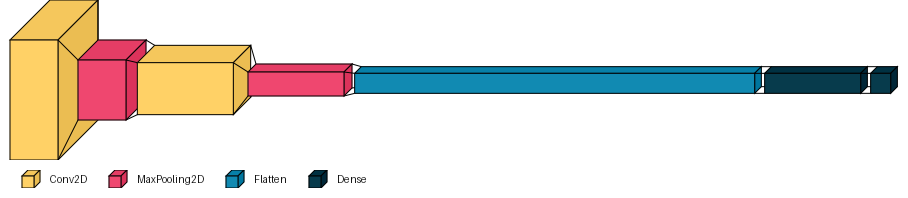

In [ ]:
#let us visualize the model
import visualkeras  #!pip install visualkeras, if it is not available to you yet
for layer in cnn_model.layers:
    layer.output_shape = layer.output.shape
visualkeras.layered_view(cnn_model, legend=True)

had to change the above model parameter to cnn_model because model is not defined

#TASK #TODO Comparison
Which model performed better and why?


The validation set for the two models is as follows:
1. ANN = 0.4963
2. CNN = 0.5938

From the above value, we can see that CNN model performed better than ANN model with a higher accuracy score compared to ANN model. This happened because ANN uses independent weights for each of the flattened inputs while CNN reuses a small shared sets of weights across the whole image. When ANN is performed, the whole array gets flattened. Therefore, the spatial features of the image such as ear being closer to eye or the eyes closer to the nose of a human face, aren't considered in ANN model. On the other hand, CNN model consideres those features. It simply shrinks the image. Due to this method, it can identify the spatial properties of the image.